## Ferramentas de Visualização - Seaborn

##### Importar pacotes

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

from house_tracker.transform import json_to_table, table_to_csv, json_to_csv
import pandas as pd
from datetime import date


##### Converter ficheiro json em tabela

## Visualização

In [1]:
def plot_analysis(df):
    # 1) Scatter com linha de tendência
    plt.figure(figsize=(8,6))
    sns.scatterplot(data=df, x='tamanho', y='preco', marker="X", s=100)
    sns.regplot(data=df, x='tamanho', y='preco', scatter=False, color="red", line_kws={"linewidth":2})
    plt.xlabel("Metros²")
    plt.ylabel("Preço (€)")
    plt.title("Relação entre Metros² e Preço com Tendência")
    plt.grid(True)
    plt.show()

    # 2) Histograma de preço por m²
    df["preco_m2"] = df["preco"] / df["tamanho"]
    plt.figure(figsize=(8,6))
    sns.histplot(df["preco_m2"], bins=20, kde=True, color="blue")
    plt.xlabel("Preço por m² (€)")
    plt.ylabel("Número de imóveis")
    plt.title("Distribuição do Preço por m²")
    plt.grid(True)
    plt.show()

    # 3) Boxplot de preço por m² por tipologia (se existir a coluna)
    if "tipologia" in df.columns:
        plt.figure(figsize=(10,6))
        sns.boxplot(data=df, x="tipologia", y="preco_m2")
        plt.xlabel("Tipologia")
        plt.ylabel("Preço por m² (€)")
        plt.title("Distribuição de Preço por m² por Tipologia")
        plt.grid(True)
        plt.show()
    else:
        print("[INFO] Coluna 'tipologia' não encontrada — a ignorar o boxplot.")

# Exemplo de uso:
# df = json_to_table("sapo/json/amadora_20250923.json")
# plot_analysis(df_preco)

In [3]:
import statsmodels.api as sm
import pandas as pd

def pontos_no_intervalo(df, xcol="tamanho", ycol="preco", alpha=0.05):
    X = sm.add_constant(df[xcol])  # adiciona termo constante
    y = df[ycol]

    modelo = sm.OLS(y, X).fit()
    previsoes = modelo.get_prediction(X).summary_frame(alpha=alpha)

    # O summary_frame dá várias colunas: mean, mean_ci_lower, mean_ci_upper, obs_ci_lower, obs_ci_upper
    df_resultado = df.copy()
    df_resultado["y_previsto"] = previsoes["mean"]
    df_resultado["ic_inf"] = previsoes["mean_ci_lower"]
    df_resultado["ic_sup"] = previsoes["mean_ci_upper"]

    # verifica se o ponto real cai dentro do IC
    df_resultado["no_ic"] = (df_resultado[ycol] >= df_resultado["ic_inf"]) & (df_resultado[ycol] <= df_resultado["ic_sup"])

    return df_resultado

resultado = pontos_no_intervalo(df)
pd.set_option("display.max_colwidth", None)# mostra texto inteiro nas células
# print(resultado[["tamanho", "preco", "y_previsto", "ic_inf", "ic_sup", "no_ic"]])
resultado[resultado["no_ic"] & (resultado["preco"] < 300000)]

NameError: name 'df' is not defined

### Lisboa

In [5]:
df = json_to_table("sapo/json/lisboa_20250924.json")
df = json_to_table("sapo/json/lisboa_20251016.json")
# print(df.shape)
# filtra fora os nulos
df = df.dropna(subset=['preco', 'tamanho'])
# # adicionar coluna preco_m2
df["preco_m2"] = df["preco"] / df["tamanho"]
# # adicionar colunas de distrito, concelho e freguesia com base na localizacao
local_split = df["localizacao"].str.split(",", expand=True)

# # Criar colunas novas
df["zona"] = local_split[0].str.strip()
df["concelho"]  = local_split[1].str.strip()
df["distrito"]  = local_split[2].str.replace("Distrito de ", "").str.strip()
df = df.sort_values(by="tamanho", ascending=False)

# carregar mapeamento
mapa = pd.read_csv("sapo/mapeamentos/mapeamento_sapo_freguesias_lisboa.csv")
# converter para dict
mapa_dict = dict(zip(mapa["zona"], mapa["freguesia_oficial"]))
# aplicar ao df
df["freguesia_oficial"] = df["zona"].map(mapa_dict)

# # filtrar pleo preco
# # filtrar imóveis com preço entre 50k e 400k
df = df[(df["preco"].between(50_000, 400_000, inclusive="both"))]
# df_desconto = df_preco[df_preco["desconto"].notnull()]
print(len(df))
print(len(df[~df["freguesia_oficial"].notnull()]))
print(len(df[df["freguesia_oficial"].notnull()]))

freguesias_em_falta = df.loc[df["freguesia_oficial"].isnull(), "zona"].unique()
print(freguesias_em_falta)
# plot_analysis(df)


830
8
822
['Bairro Alto (Santa Catarina)' 'Sapadores (São Vicente de Fora)'
 'Calçada dos Barbadinhos' 'Centro (Santo Condestável)'
 'Avenidas Novas (São João de Deus)' 'Largo do Caldas (Castelo)']


### Amadora

127
4
123
['Damaia de Cima' 'Centro (Brandoa)']


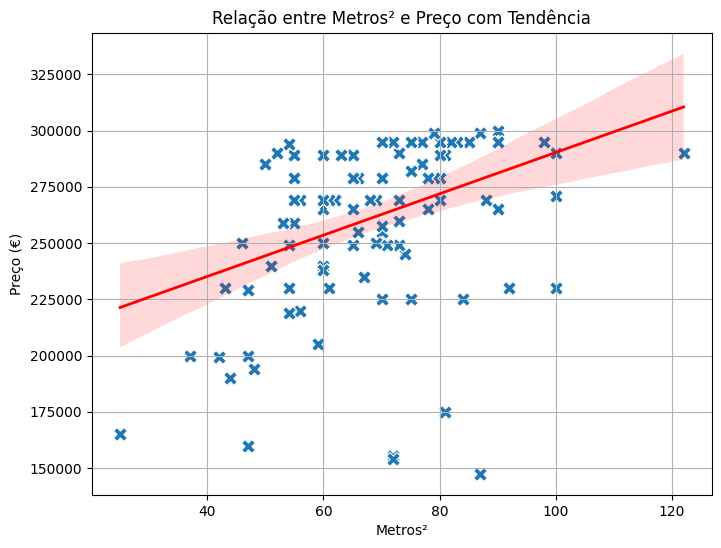

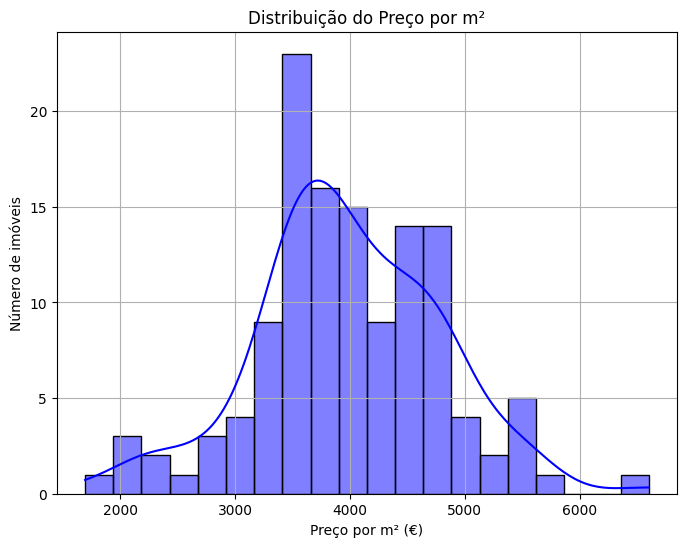

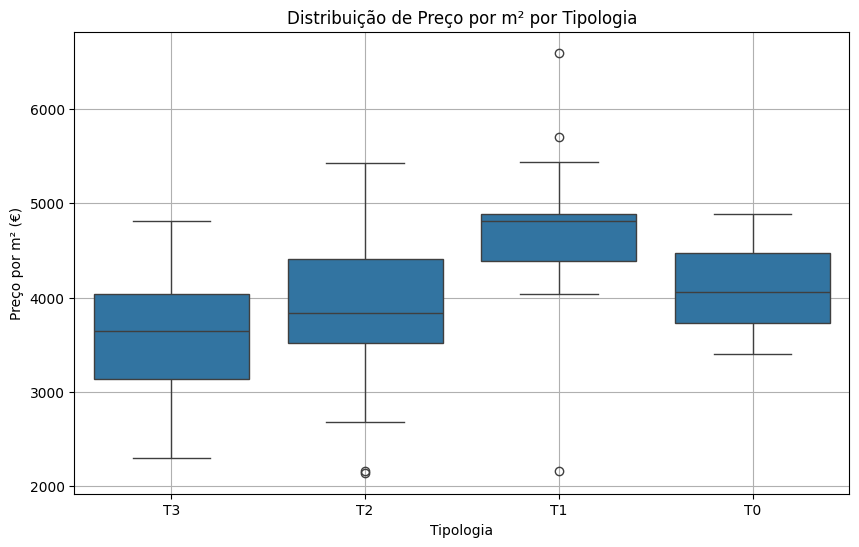

In [6]:
df = json_to_table("sapo/json/amadora_20250929.json")
# print(df.shape)
# filtra fora os nulos
df = df.dropna(subset=['preco', 'tamanho'])
# # adicionar coluna preco_m2
df["preco_m2"] = df["preco"] / df["tamanho"]
# # adicionar colunas de distrito, concelho e freguesia com base na localizacao
local_split = df["localizacao"].str.split(",", expand=True)

# # Criar colunas novas
df["zona"] = local_split[0].str.strip()
df["concelho"]  = local_split[1].str.strip()
df["distrito"]  = local_split[2].str.replace("Distrito de ", "").str.strip()
df = df.sort_values(by="tamanho", ascending=False)

# carregar mapeamento
mapa = pd.read_csv("sapo/mapeamentos/mapeamento_sapo_freguesias_amadora.csv")
# converter para dict
mapa_dict = dict(zip(mapa["zona"], mapa["freguesia_oficial"]))
# aplicar ao df
df["freguesia_oficial"] = df["zona"].map(mapa_dict)

# # filtrar pleo preco
# # filtrar imóveis com preço entre 50k e 300k
df = df[(df["preco"].between(50_000, 300_000, inclusive="both"))]
# df_desconto = df_preco[df_preco["desconto"].notnull()]
print(len(df))
print(len(df[~df["freguesia_oficial"].notnull()]))
print(len(df[df["freguesia_oficial"].notnull()]))

freguesias_em_falta = df.loc[df["freguesia_oficial"].isnull(), "zona"].unique()
print(freguesias_em_falta)
# print(df["zona"].unique())
plot_analysis(df)

### Sintra

In [150]:

df = json_to_table("sapo/json/sintra_20250925.json")
# print(df.shape)
# filtra fora os nulos
df = df.dropna(subset=['preco', 'tamanho'])
# # adicionar coluna preco_m2
df["preco_m2"] = df["preco"] / df["tamanho"]
# # adicionar colunas de distrito, concelho e freguesia com base na localizacao
local_split = df["localizacao"].str.split(",", expand=True)

# # Criar colunas novas
df["zona"] = local_split[0].str.strip()
df["concelho"]  = local_split[1].str.strip()
df["distrito"]  = local_split[2].str.replace("Distrito de ", "").str.strip()
df = df.sort_values(by="tamanho", ascending=False)

# carregar mapeamento
mapa = pd.read_csv("sapo/mapeamentos/mapeamento_sapo_freguesias_sintra.csv")
# converter para dict
mapa_dict = dict(zip(mapa["zona"], mapa["freguesia_oficial"]))
# aplicar ao df
df["freguesia_oficial"] = df["zona"].map(mapa_dict)

# # filtrar pleo preco
# # filtrar imóveis com preço entre 50k e 400k
df = df[(df["preco"].between(50_000, 400_000, inclusive="both"))]
df = df[(df["tamanho"].between(30, 160, inclusive="both"))]
# df_desconto = df_preco[df_preco["desconto"].notnull()]
# print(len(df))
# print(len(df[~df["freguesia_oficial"].notnull()]))
# print(len(df[df["freguesia_oficial"].notnull()]))

freguesias_em_falta = df.loc[df["freguesia_oficial"].isnull(), "zona"].unique()
# print(freguesias_em_falta)
# print(df["zona"].unique())
# plot_analysis(df)
df

,pagina,id,titulo,link,tipologia,estado,tamanho,preco,preco_antigo,desconto,localizacao,data_publicacao,data_extracao,preco_m2,zona,concelho,distrito,freguesia_oficial
680,28,4,"Ver Apartamento T4 para comprar em Sintra, Alg...",https://casa.sapo.pt/comprar-apartamento-t4-si...,T4,Usado,150.0,375000,None,None,"Algueirão-Mem Martins, Sintra, Distrito de Lisboa",None,20250925,2500.000000,Algueirão-Mem Martins,Sintra,Lisboa,Algueirão-Mem Martins
699,28,23,"Ver Apartamento T4 para comprar em Sintra, Rio...",https://casa.sapo.pt/comprar-apartamento-t4-si...,T4,Recuperado,150.0,289000,None,None,"Rio de Mouro, Sintra, Distrito de Lisboa",None,20250925,1926.666667,Rio de Mouro,Sintra,Lisboa,Rio de Mouro
545,22,19,"Ver Apartamento T3 para comprar em Sintra, Mas...",https://casa.sapo.pt/comprar-apartamento-t3-si...,T3,Renovado,141.0,370000,None,None,"Massamá e Monte Abraão, Sintra, Distrito de Li...",None,20250925,2624.113475,Massamá e Monte Abraão,Sintra,Lisboa,Massamá e Monte Abraão
446,18,20,"Ver Duplex T4 para comprar em Sintra, Algueirã...",https://casa.sapo.pt/comprar-duplex-t4-sintra-...,T4,Usado,140.0,380000,None,None,"Mercês, Algueirão-Mem Martins, Sintra, Distrit...",None,20250925,2714.285714,Mercês,Algueirão-Mem Martins,Sintra,Algueirão-Mem Martins
46,2,20,"Ver Apartamento T3 para comprar em Sintra, Mas...",https://casa.sapo.pt/comprar-apartamento-t3-si...,T3,Usado,140.0,337500,None,None,"Massamá e Monte Abraão, Sintra, Distrito de Li...",None,20250925,2410.714286,Massamá e Monte Abraão,Sintra,Lisboa,Massamá e Monte Abraão
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
670,27,19,"Ver Apartamento T1 para comprar em Sintra, Que...",https://casa.sapo.pt/comprar-apartamento-t1-si...,T1,Usado,42.0,200000,None,None,"Queluz e Belas, Sintra, Distrito de Lisboa",None,20250925,4761.904762,Queluz e Belas,Sintra,Lisboa,Queluz e Belas
355,15,4,"Ver Apartamento T1 para comprar em Sintra, Alg...",https://casa.sapo.pt/comprar-apartamento-t1-si...,T1,Usado,40.0,190000,None,None,"Algueirão-Mem Martins, Sintra, Distrito de Lisboa",None,20250925,4750.000000,Algueirão-Mem Martins,Sintra,Lisboa,Algueirão-Mem Martins
518,21,17,"Ver Apartamento T1 para comprar em Sintra, Mas...",https://casa.sapo.pt/comprar-apartamento-t1-si...,T1,Usado,38.0,178000,None,None,"Massamá e Monte Abraão, Sintra, Distrito de Li...",None,20250925,4684.210526,Massamá e Monte Abraão,Sintra,Lisboa,Massamá e Monte Abraão
273,11,22,"Ver Apartamento T1 para comprar em Sintra, Mas...",https://casa.sapo.pt/comprar-apartamento-t1-si...,T1,Usado,38.0,200000,None,None,"Massamá e Monte Abraão, Sintra, Distrito de Li...",None,20250925,5263.157895,Massamá e Monte Abraão,Sintra,Lisboa,Massamá e Monte Abraão


### Scatter (Preço vs tamanho, cor por freguesia)

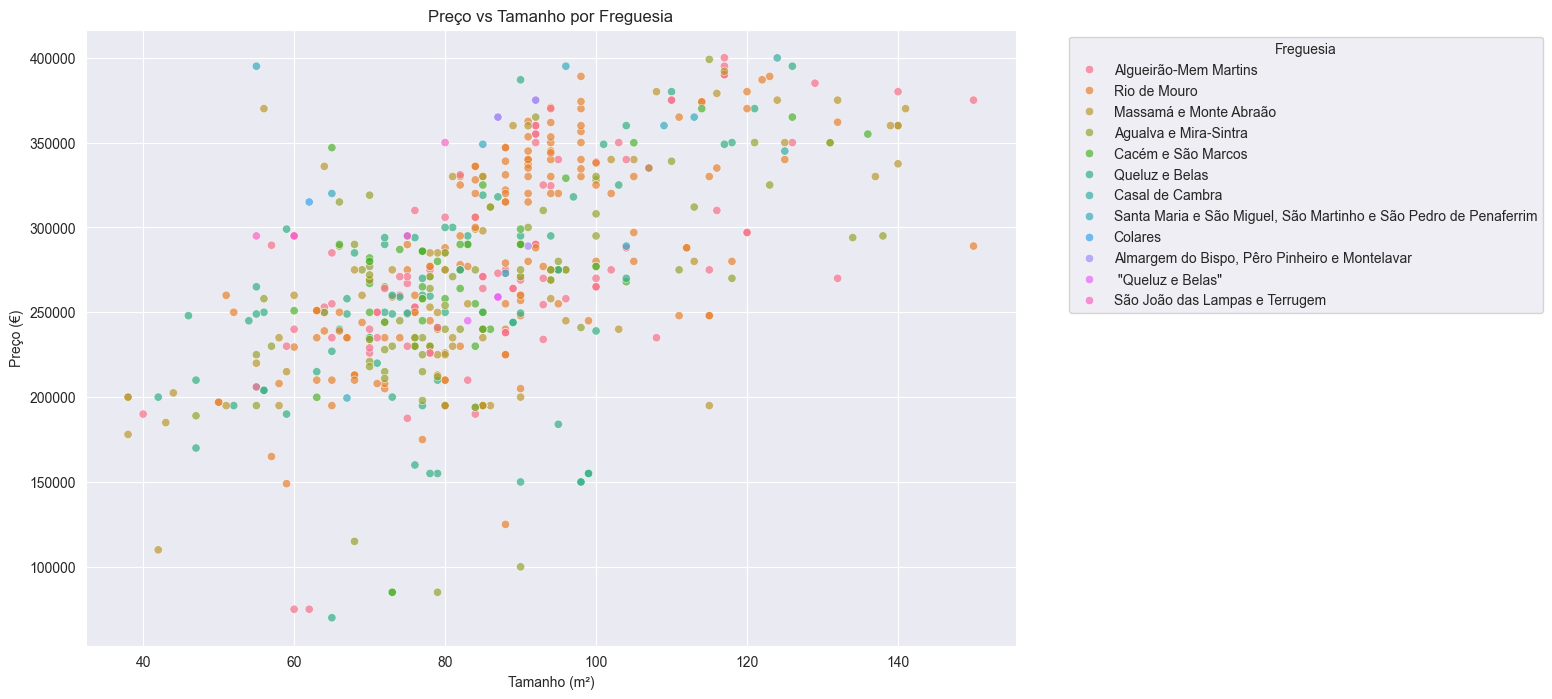

In [151]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x="tamanho", y="preco", hue="freguesia_oficial", alpha=0.7)

plt.xlabel("Tamanho (m²)")
plt.ylabel("Preço (€)")
plt.title("Preço vs Tamanho por Freguesia")
plt.legend(title="Freguesia", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.show()

### Gráfico Preço/m2 por Freguesia

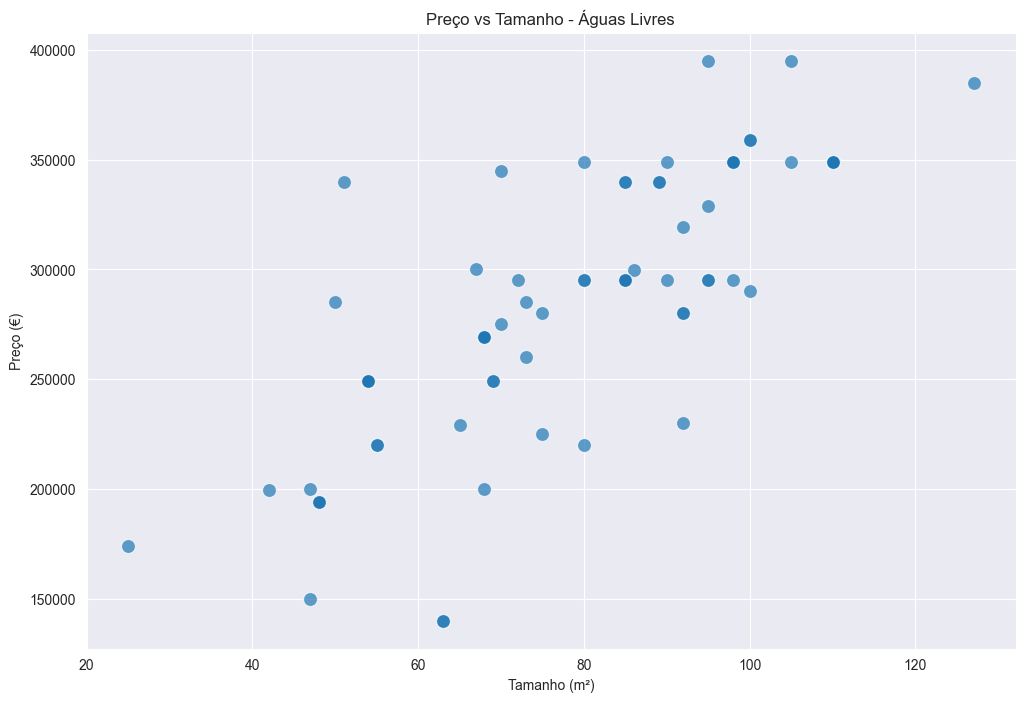

In [135]:
def plot_boxplot(df, export=False):
    df = df.copy()  # evita alterar df original
    df["preco_m2"] = df["preco"] / df["tamanho"]

    plt.figure(figsize=(14, 8))
    sns.boxplot(data=df, x="freguesia_oficial", y="preco_m2")
    plt.xticks(rotation=90)
    plt.xlabel("Freguesia")
    plt.ylabel("Preço por m² (€)")
    plt.title("Distribuição do Preço por m² por Freguesia")

    # exportar
    if export:
        plt.savefig("graficos/preco_m2_por_freguesia.png", dpi=300, bbox_inches="tight")
        print("Gráfico salvo como 'graficos/preco_m2_por_freguesia.png'")
        plt.close()
    else:
        plt.show()


def plot_preco_tamanho_por_freguesia(df, freguesia=None, export=False):
    """
    Faz scatterplot de Preço vs Tamanho para imóveis.
    - Se freguesia=None, mostra todas as freguesias no mesmo gráfico.
    - Se freguesia="Benfica" (por ex.), filtra e mostra apenas essa freguesia.
    """
    data = df.copy()

    if freguesia:
        data = data[data["freguesia_oficial"] == freguesia]
        title = f"Preço vs Tamanho - {freguesia}"
    else:
        title = "Preço vs Tamanho por Freguesia"

    plt.figure(figsize=(12, 8))
    sns.scatterplot(
        data=data, 
        x="tamanho", 
        y="preco", 
        hue="freguesia_oficial" if freguesia is None else None, 
        alpha=0.7, s=100
    )

    plt.xlabel("Tamanho (m²)")
    plt.ylabel("Preço (€)")
    plt.title(title)
    plt.grid(True)

    if export:
        filename = f"graficos/preco_vs_tamanho_{freguesia if freguesia else 'todas'}.png"
        plt.savefig(filename, dpi=300, bbox_inches="tight")
        plt.close()
        print(f"[INFO] Gráfico salvo em {filename}")
    else:
        plt.show()


# plot_boxplot(df, export=False)
plot_preco_tamanho_por_freguesia(df, freguesia='Águas Livres', export=False)


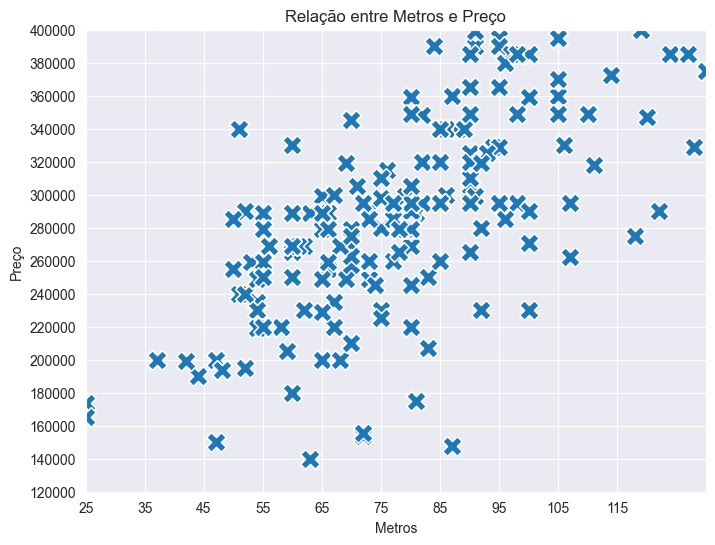

In [40]:
def plot_scatter(df):
    plt.figure(figsize=(8, 6))

    # Adiciona o gráfico de dispersão
    sns.scatterplot(data=df, x='tamanho', y='preco', marker="X", s=200)

    # Altere para o estilo desejado
    sns.set_style("darkgrid")  

    # Configurar Escala
    plt.xlim(25, 130)
    plt.xticks(range(25, 121, 10))
    plt.ylim(120_000, 400_000)
    plt.yticks(range(120_000, 401_000, 20_000))

    # Definir Eixos e Título
    plt.xlabel('Metros')
    plt.ylabel('Preço')
    plt.title('Relação entre Metros e Preço')
    plt.grid(True)
    plt.show()

plot_scatter(df)



Visualização - Heatmap

<Axes: xlabel='tamanho', ylabel='preco'>

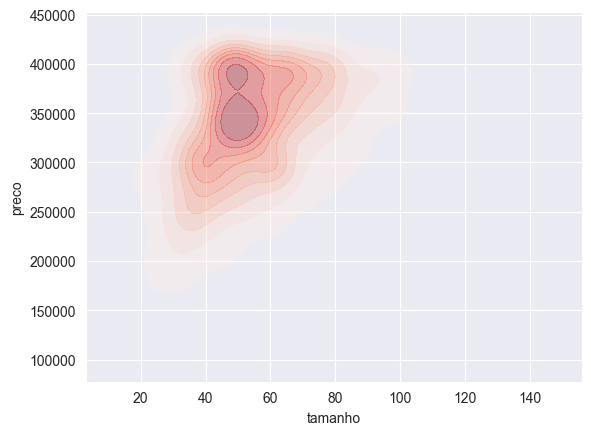

In [80]:
# Adiciona o heatmap de densidade
sns.kdeplot(
    data=df,
    x="tamanho",
    y="preco",
    fill=True,
    cmap="Reds",
    alpha=0.4,
    thresh=0.05
)

### MAPA DE PORTUGAL

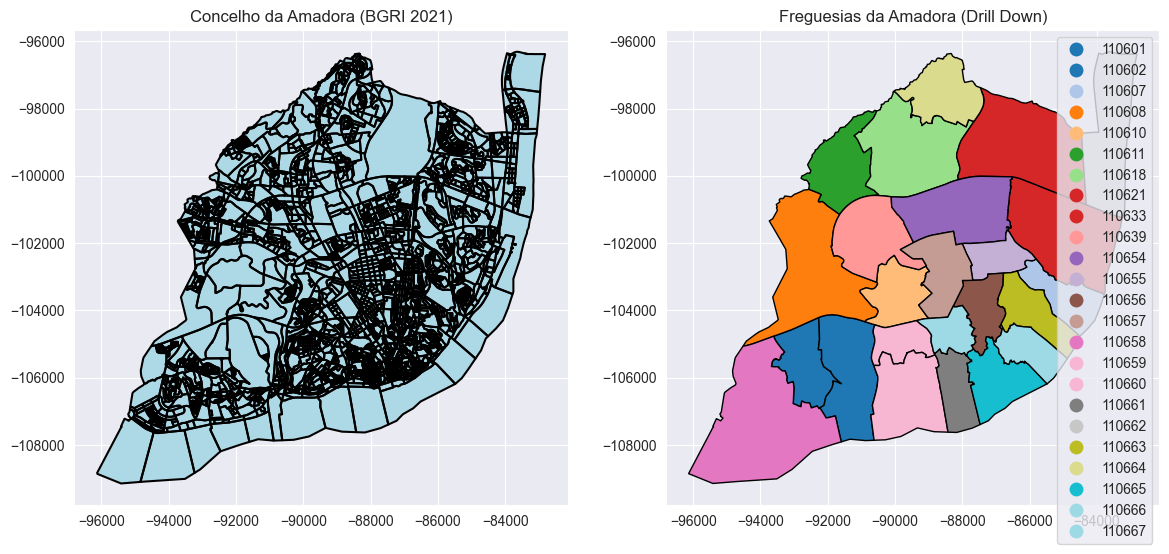

In [46]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Caminho para o ficheiro GPKG dentro da tua pasta
gpkg_file = "geodata/BGRI2021_1106.gpkg"

# Carregar todos os polígonos do município da Amadora
amadora = gpd.read_file(gpkg_file)

# Dissolver por código de freguesia (DTMNFR21) para obter freguesias
amadora_freguesias = amadora.dissolve(by="DTMNFR21").reset_index()

# --- Plot Drill Down ---
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# (a) Todo o concelho da Amadora
amadora.boundary.plot(ax=axes[0], color="black")
amadora.plot(ax=axes[0], color="lightblue", edgecolor="white")
axes[0].set_title("Concelho da Amadora (BGRI 2021)")

# (b) Freguesias da Amadora
amadora_freguesias.plot(ax=axes[1], column="DTMNFR21", cmap="tab20", legend=True, edgecolor="black")
axes[1].set_title("Freguesias da Amadora (Drill Down)")

plt.show()

In [54]:
import geopandas as gpd

gpkg_file = "geodata/BGRI2021_1106.gpkg"
amadora = gpd.read_file(gpkg_file)
freguesia_lookup = {
    "110604": "Águas Livres",
    "110605": "Alfragide",
    "110606": "Encosta do Sol",
    "110607": "Falagueira-Venda Nova",
    "110608": "Mina de Água",
    "110609": "Venteira"
}
amadora["freguesia_nome"] = amadora["DTMNFR21"].map(freguesia_lookup)

# print(amadora.columns)
amadora.head(
)

,OBJECTID,BGRI2021,DT21,DTMN21,DTMNFR21,DTMNFRSEC21,SECNUM21,SSNUM21,SECSSNUM21,SUBSECCAO,...,N_INDIVIDUOS_H,N_INDIVIDUOS_M,N_INDIVIDUOS_0_14,N_INDIVIDUOS_15_24,N_INDIVIDUOS_25_64,N_INDIVIDUOS_65_OU_MAIS,SHAPE_Length,SHAPE_Area,geometry,freguesia_nome
0,30243,11065602301,11,1106,110656,110656023,023,01,02301,11065602301,...,106.0,96.0,14.0,31.0,127.0,30.0,409.853268,9657.766943,"MULTIPOLYGON (((-86809.545 -103264.238, -86801...",NaN
1,30244,11065700203,11,1106,110657,110657002,002,03,00203,11065700203,...,75.0,122.0,26.0,24.0,85.0,62.0,368.048569,8445.226728,"MULTIPOLYGON (((-88183.921 -103236.85, -88218....",NaN
2,30311,11065801011,11,1106,110658,110658010,010,11,01011,11065801011,...,12.0,9.0,4.0,5.0,9.0,3.0,239.674582,2582.412127,"MULTIPOLYGON (((-94424.359 -107038.246, -94495...",NaN
3,30312,11065801012,11,1106,110658,110658010,010,12,01012,11065801012,...,8.0,12.0,4.0,2.0,7.0,7.0,250.811945,3077.844919,"MULTIPOLYGON (((-94547.783 -107023.019, -94626...",NaN
4,30313,11065801013,11,1106,110658,110658010,010,13,01013,11065801013,...,9.0,13.0,7.0,3.0,8.0,4.0,238.956181,2555.620562,"MULTIPOLYGON (((-94440.784 -107017.804, -94514...",NaN


### Mapa de Lisboa por Freguesia (Imovirtual)

In [ ]:
import geopandas as gpd
from matplotlib.colors import LinearSegmentedColormap

df_imovirtual_lisboa = json_to_table("imovirtual/json/lisboa_20260713.json")
# alguns anúncios da pesquisa "lisboa" pertencem na verdade a concelhos vizinhos
# (geocodificação do próprio site) — filtrar para o concelho de Lisboa
df_imovirtual_lisboa = df_imovirtual_lisboa[df_imovirtual_lisboa["concelho"] == "Lisboa"]
df_imovirtual_lisboa = df_imovirtual_lisboa.dropna(subset=["preco_por_metro"])

stats_freguesia = df_imovirtual_lisboa.groupby("freguesia").agg(
    preco_m2_mediano=("preco_por_metro", "median"),
    n_imoveis=("id", "count"),
).reset_index()

gdf_lisboa = gpd.read_file("geodata/lisboa_freguesias.geojson")
gdf_lisboa = gdf_lisboa.merge(stats_freguesia, on="freguesia", how="left")

# rampa sequencial azul (paleta de referência do dataviz skill)
blue_ramp = ["#cde2fb", "#9ec5f4", "#5598e7", "#2a78d6", "#1c5cab", "#0d366b"]
cmap = LinearSegmentedColormap.from_list("seq_blue", blue_ramp)

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
gdf_lisboa.plot(
    column="preco_m2_mediano",
    cmap=cmap,
    linewidth=0.6,
    edgecolor="white",
    ax=ax,
    legend=True,
    legend_kwds={"label": "Preço mediano por m² (€)", "shrink": 0.6},
    missing_kwds={"color": "#e5e5e2", "label": "Sem dados"},
)
ax.set_title("Preço mediano por m² por freguesia — Lisboa (Imovirtual)", fontsize=13)
ax.axis("off")
plt.tight_layout()
plt.savefig("graficos/preco_m2_por_freguesia_lisboa.png", dpi=200, bbox_inches="tight")
plt.show()
